# SASHIMI-W standard API walkthrough

Use the installed package from any working directory. The candidate package
requires the locally supplied `sashimi-itamae` wheel until release publication.
The standard thermal-WDM prescription uses q10, the square of the Viel
transfer amplitude. The old q5 selector is rejected; frozen q5 references
preserve historical reproduction. The default half-mode is amplitude half.

The small grid demonstrates the API and is not a converged abundance prediction.

In [1]:
from pathlib import Path
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import sashimi_w
from sashimi_w import Subhalos
from itamae.types import WeightedSubhaloCatalog
from itamae.provenance import source_revision

print("W source:", source_revision("sashimi-w", module_file=sashimi_w.__file__))
model = Subhalos(mass_wdm=2.0)
parameters = dict(M0=1e10, redshift=0., dz=.5, zmax=1., N_ma=4,
                  N_herm=2, N_hermNa=3, logmamin=6., logmamax=8.)
catalog = model.rs_rhos_catalog_calc(**parameters)
assert catalog.shape == (16,)
print(catalog.metadata["calculation_specification"])
print("Expected surviving subhalos on this grid:", catalog.weight_final.sum())

W source: e3017d93b4dfdcb975bca71f1a00535e8faf4ec2


sashimi-w:thermal-wdm-q10:2026-09-11:v2
Expected surviving subhalos on this grid: 2.3412932284910266e-06


In [2]:
k_amplitude_half = model.half_mode_wavenumber()
k_power_half = model.half_mode_wavenumber(power_ratio=0.5)
assert np.isclose(model.power_ratio(k_amplitude_half), 0.25)
assert np.isclose(model.power_ratio(k_power_half), 0.5)
print("Half-mode k [h/Mpc]: amplitude half", k_amplitude_half, "; power half", k_power_half)

Half-mode k [h/Mpc]: amplitude half 20.114255416329843 ; power half 14.502530777369888


The named catalog uses physical solar masses, megaparsecs and solar masses
per cubic megaparsec. `weight_base`, `weight_concentration` and
`weight_survival` remain separate. The final weight is their product.

In [3]:
for name in ("m200_acc", "m_bound", "r_s", "rho_s", "c_t"):
    assert np.isfinite(catalog.columns[name]).all()
assert (catalog.weight_final >= 0).all()
assert (catalog.columns["m_bound"] <= catalog.columns["m200_acc"]).all()
assert np.array_equal(catalog.columns["survive"], catalog.columns["c_t"] > .77)
print("Units:", catalog.metadata["canonical_units"])
print("Weight factors:", sorted(catalog.weights))

Units: {'mass': 'Msun', 'length': 'Mpc', 'density': 'Msun/Mpc^3'}
Weight factors: ['weight_base', 'weight_concentration', 'weight_survival']


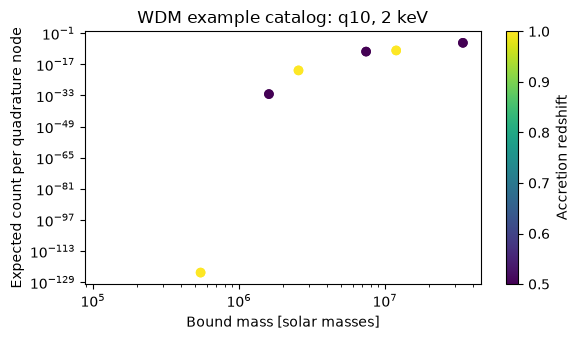

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
points = ax.scatter(catalog.columns["m_bound"], catalog.weight_final,
           c=catalog.columns["z_acc"], cmap="viridis", s=35)
ax.set(xscale="log", yscale="log", xlabel="Bound mass [solar masses]",
       ylabel="Expected count per quadrature node", title="WDM example catalog: q10, 2 keV")
fig.colorbar(points, ax=ax, label="Accretion redshift")
fig.tight_layout()
plt.show()

In [5]:
with tempfile.TemporaryDirectory() as directory:
    path = Path(directory) / "wdm-catalog.npz"
    catalog.to_npz(path)
    restored = WeightedSubhaloCatalog.from_npz(path)
    np.testing.assert_array_equal(restored.weight_final, catalog.weight_final)
    assert dict(restored.metadata) == dict(catalog.metadata)
print("Serialization preserved columns, independent weights and provenance.")

Serialization preserved columns, independent weights and provenance.


`rs_rhos_calc` converts the same calculation to a ten-element tuple
(Msun, kpc, Msun/pc³); tuple weight excludes survival. `subhalo_distr`, `N_sat`
and `N_sat_Vthres` now apply the same survivor selection. `accretion=True`
displays survivors by accretion mass. `N_sat` returns a curve against accretion
mass; `N_sat_Vthres` uses current Vmax. Both count strict values above their
returned thresholds and return the full selected weight sum separately.

The separate scientific-validation notebook compares independent frozen
references and checks the continuous variance derivative. No legacy runtime
or `physics_mode` parameter remains in the standard API.